# Detecting Malicious URLs with Lexical Features
**Arturo Gourentchik, Lachlan Carlsen, Mark Lester Apuya**  
Department of Computer Science – San Diego State University  
CS 549: Machine Learning. 
{agourentchik7972, lcarlsen7906, mapuya5582}@sdsu.edu  

## Section 1: Import Libraries
Import all necessary Python libraries for data manipulation, URL parsing, machine learning, model evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np

from urllib.parse import urlparse
import tldextract

from scipy.stats import entropy
from collections import Counter
import math

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

import time

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## Section 2: Load Data & Overiew 
Load the malicious/benign URL dataset and perform initial exploration to understand its structure, size, and data types.

### 2.1 Load Dataset
Load the CSV dataset containing URLs and their labels (benign=0, malicious=1).

In [2]:
# Load the dataset
df = pd.read_csv('urldata.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 10 rows:")
df.head(10)

Dataset Shape: (450176, 4)

Column Names: ['Unnamed: 0', 'url', 'label', 'result']

Data Types:
Unnamed: 0     int64
url           object
label         object
result         int64
dtype: object

First 10 rows:


,Unnamed: 0,url,label,result
0,0,https://www.google.com,benign,0
1,1,https://www.youtube.com,benign,0
2,2,https://www.facebook.com,benign,0
3,3,https://www.baidu.com,benign,0
4,4,https://www.wikipedia.org,benign,0
5,5,https://www.reddit.com,benign,0
6,6,https://www.yahoo.com,benign,0
7,7,https://www.google.co.in,benign,0
8,8,https://www.qq.com,benign,0
9,9,https://www.amazon.com,benign,0


### 2.2 Exploratory Data Analysis
Examine dataset statistics, check for missing values, and understand the distribution of features.

## DATASET OVERVIEW


Total URLs: 450,176

Missing Values:
Unnamed: 0    0
url           0
label         0
result        0
dtype: int64

Duplicate Rows: 0


## CLASS DISTRIBUTION


Label Counts:
label
benign       345738
malicious    104438
Name: count, dtype: int64

Label Proportions:
label
benign       0.768006
malicious    0.231994
Name: proportion, dtype: float64


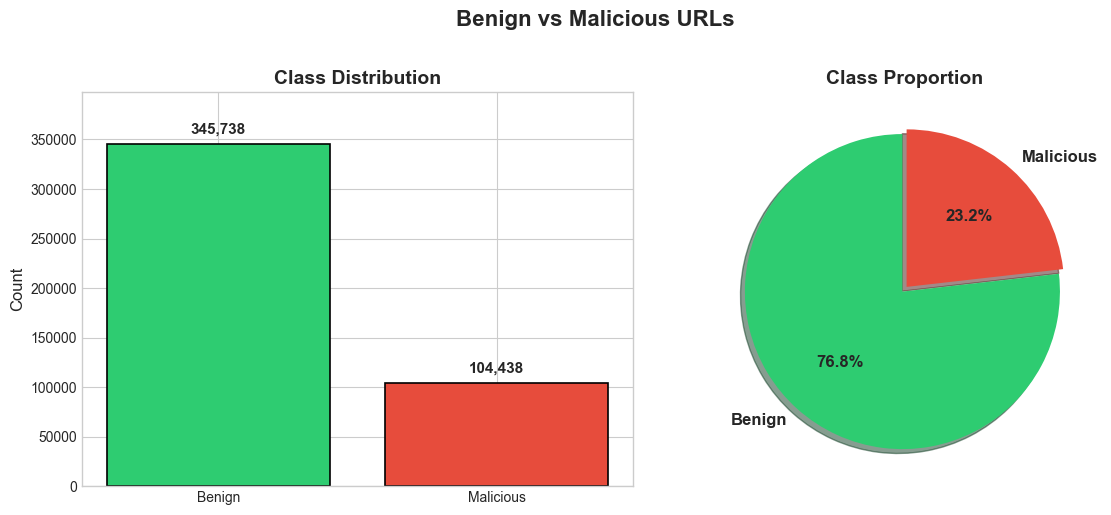

In [3]:
# Basic statistics
from IPython.display import display, Markdown, HTML
display(Markdown("## DATASET OVERVIEW"))

print(f"\nTotal URLs: {len(df):,}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum():,}")

# Class distribution
from IPython.display import display, Markdown, HTML
display(Markdown("## CLASS DISTRIBUTION"))

print(f"\nLabel Counts:\n{df['label'].value_counts()}")
print(f"\nLabel Proportions:\n{df['label'].value_counts(normalize=True)}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']  # Green for benign, Red for malicious
counts = df['label'].value_counts().sort_index()
bars = axes[0].bar(['Benign', 'Malicious'], counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_ylim(0, counts.max() * 1.15)

# Add count labels on bars
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.02, 
                 f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Benign', 'Malicious'], colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0.02, 0.02), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Benign vs Malicious URLs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Sample URLs and Labels
Display example URLs from both benign and malicious classes to understand the data patterns.

In [9]:
# Sample benign URLs
from IPython.display import display, Markdown, HTML
display(Markdown("## SAMPLE BENIGN URLs"))
benign_urls = df[df['result'] == 0]['url'].sample(5, random_state=42)
for url in benign_urls:
    print(url)

# Sample malicious URLs
from IPython.display import display, Markdown, HTML
display(Markdown("## SAMPLE MALICIOUS URLs"))
malicious_urls = df[df['result'] == 1]['url'].sample(5, random_state=42)
for url in malicious_urls:
    print(url)

# PRELIMINARY LEXICAL PATTERN ANALYSIS
from IPython.display import display, Markdown, HTML
display(Markdown("## PRELIMINARY LEXICAL PATTERN ANALYSIS"))

# Create temporary features for exploration
temp_df = df.copy()
temp_df['url_length'] = temp_df['url'].apply(len)
temp_df['num_dots'] = temp_df['url'].apply(lambda x: x.count('.'))
temp_df['num_slashes'] = temp_df['url'].apply(lambda x: x.count('/'))
temp_df['num_digits'] = temp_df['url'].apply(lambda x: sum(c.isdigit() for c in x))
temp_df['num_special'] = temp_df['url'].apply(lambda x: sum(c in '-_@?&=%#' for c in x))
temp_df['has_https'] = temp_df['url'].apply(lambda x: 1 if x.startswith('https') else 0)
temp_df['has_ip'] = temp_df['url'].apply(lambda x: 1 if any(c.isdigit() and '.' in x[max(0,x.find(c)-3):x.find(c)+4] for c in x) else 0)

# Compare means by class
features = ['url_length', 'num_dots', 'num_slashes', 'num_digits', 'num_special', 'has_https']
comparison = temp_df.groupby('result')[features].mean().T
comparison.columns = ['Benign', 'Malicious']
comparison['Difference'] = comparison['Malicious'] - comparison['Benign']
print("\nMean Feature Values by Class:")
print(comparison.round(2))

# HTTPS usage comparison
from IPython.display import display, Markdown, HTML
display(Markdown("## HTTPS USAGE BY CLASS"))
https_stats = temp_df.groupby('result')['has_https'].mean() * 100
print(f"Benign URLs using HTTPS: {https_stats[0]:.1f}%")
print(f"Malicious URLs using HTTPS: {https_stats[1]:.1f}%")

# www usage comparison
from IPython.display import display, Markdown, HTML
display(Markdown("## www. USAGE BY CLASS"))
temp_df['has_www'] = temp_df['url'].apply(lambda x: 1 if 'www.' in x else 0)
www_stats = temp_df.groupby('result')['has_www'].mean() * 100
print(f"Benign URLs using www: {www_stats[0]:.1f}%")
print(f"Malicious URLs using www: {www_stats[1]:.1f}%")

del temp_df

## SAMPLE BENIGN URLs

https://www.yelp.com/biz/stone-mountain-clay-and-glaze-tucker
https://www.ivanhill5478.blogspot.com/
https://www.facebook.com/people/Reggie-Walton/1070104441
https://www.freepages.genealogy.rootsweb.ancestry.com/~dwdrury/abell/index3.htm
https://www.manchester.edu/Athletics/basketballm/moreNews.htm


## SAMPLE MALICIOUS URLs

http://educatingwellness.com/ServiceE/78c95/home?webapps/mpp/merchant
http://grupodoma.com.mx/dropbox/mail.126.com/accounts.php
http://cke8q1.lucirabydevpps.info/zla4u55jxc\nwww.doblatuproductividad.com/000ded60ea040d013384ba6eac24fdf1.php?q=00d99394125a37085e8f4f81ddee3c18
http://www.dimplexx.net/offer001/
http://rubialage.com.br/store/css/


## PRELIMINARY LEXICAL PATTERN ANALYSIS


Mean Feature Values by Class:
             Benign  Malicious  Difference
url_length    58.48      66.05        7.57
num_dots       2.65       2.52       -0.14
num_slashes    4.30       4.93        0.63
num_digits     3.28       7.23        3.96
num_special    2.42       1.91       -0.51
has_https      1.00       0.06       -0.94


## HTTPS USAGE BY CLASS

Benign URLs using HTTPS: 100.0%
Malicious URLs using HTTPS: 6.2%


## www. USAGE BY CLASS

Benign URLs using www: 99.8%
Malicious URLs using www: 14.8%


## Section 3: Data Preprocessing
Clean, normalize, and transform raw URLs into a structured feature set suitable for machine learning models.

### 3.1 Handling Missing or Invalid URLs
Identify and remove records with missing, empty, or unparseable URL strings.

In [ ]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.1 HANDLING MISSING OR INVALID URLs"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")
print(f"[INPUT] Sample:\n{df[['url', 'label', 'result']].head(3)}")

# Track initial count
initial_count = len(df)

# Remove rows with missing URLs
df = df.dropna(subset=['url'])

# Remove empty strings
df = df[df['url'].str.strip() != '']

# Remove URLs that can't be parsed
def is_valid_url(url):
    try:
        result = urlparse(url)
        return all([result.scheme or url.startswith('www'), len(url) > 5])
    except:
        return False

df = df[df['url'].apply(is_valid_url)]

# OUTPUT
removed_count = initial_count - len(df)
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] Removed: {removed_count:,} invalid/missing URLs")
print(f"[OUTPUT] Remaining: {len(df):,} valid URLs")

## 3.1 HANDLING MISSING OR INVALID URLs


[INPUT] Shape: (450176, 4)
[INPUT] Sample:
                        url   label  result
0    https://www.google.com  benign       0
1   https://www.youtube.com  benign       0
2  https://www.facebook.com  benign       0

[OUTPUT] Shape: (450175, 4)
[OUTPUT] Removed: 1 invalid/missing URLs
[OUTPUT] Remaining: 450,175 valid URLs


### 3.2 Remove Duplicate URLs
Eliminate duplicate URLs to prevent data leakage and training bias.

In [6]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.2 REMOVE DUPLICATE URLs"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")
print(f"[INPUT] Duplicate count: {df.duplicated(subset=['url']).sum():,}")

# Track initial count
initial_count = len(df)

# Remove exact duplicate URLs (keep first occurrence)
df = df.drop_duplicates(subset=['url'], keep='first')

# Reset index
df = df.reset_index(drop=True)

# OUTPUT
removed_count = initial_count - len(df)
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] Removed: {removed_count:,} duplicate URLs")
print(f"[OUTPUT] Remaining: {len(df):,} unique URLs")

## 3.2 REMOVE DUPLICATE URLs


[INPUT] Shape: (450175, 4)
[INPUT] Duplicate count: 0

[OUTPUT] Shape: (450175, 4)
[OUTPUT] Removed: 0 duplicate URLs
[OUTPUT] Remaining: 450,175 unique URLs


### 3.3 URL Normalization 
Standardize URLs by lowercasing, removing fragments, stripping default ports, and collapsing repeated slashes.

In [ ]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.3 URL NORMALIZATION"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")
print(f"[INPUT] Sample URLs:")
for url in df['url'].head(3):
    print(f"  {url}")

def normalize_url(url):
    # Lowercase the URL
    url = url.lower()
    
    # Remove fragments (#section)
    if '#' in url:
        url = url.split('#')[0]
    
    # Remove trailing slashes
    url = url.rstrip('/')
    
    # Remove default ports (:80 for http, :443 for https)
    url = url.replace(':80/', '/').replace(':443/', '/')
    url = url.replace(':80', '').replace(':443', '')
    
    # Collapse multiple slashes
    if '://' in url:
        protocol, rest = url.split('://', 1)
        rest = '/'.join(filter(None, rest.split('/')))
        url = f"{protocol}://{rest}"
    
    return url

# Apply normalization
df['url_normalized'] = df['url'].apply(normalize_url)

# OUTPUT
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] New column added: 'url_normalized'")

# Find modified URLs
modified_urls = df[df['url'] != df['url_normalized']]
print(f"[OUTPUT] URLs modified: {len(modified_urls):,} ({len(modified_urls)/len(df)*100:.2f}%)")

# Modified URLs
if len(modified_urls) > 0:
    print(f"\n[OUTPUT] Sample MODIFIED URLs:")
    for i, row in modified_urls[['url', 'url_normalized']].sample(min(5, len(modified_urls)), random_state=42).iterrows():
        print(f"  Original:   {row['url']}")
        print(f"  Normalized: {row['url_normalized']}\n")
else:
    print(f"\n[OUTPUT] No URLs required normalization changes.")
    print(f"[OUTPUT] Sample URLs (unchanged):")
    for i, row in df[['url', 'url_normalized']].sample(3, random_state=42).iterrows():
        print(f"  {row['url']}")

print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 10 rows:")
df.head(10)

## 3.3 URL NORMALIZATION


[INPUT] Shape: (450175, 4)
[INPUT] Sample URLs:
  https://www.google.com
  https://www.youtube.com
  https://www.facebook.com

[OUTPUT] Shape: (450175, 5)
[OUTPUT] New column added: 'url_normalized'
[OUTPUT] URLs modified: 258,697 (57.47%)

[OUTPUT] Sample MODIFIED URLs:
  Original:   https://www.encyclopedia.com/topic/Vietnam_War.aspx
  Normalized: https://www.encyclopedia.com/topic/vietnam_war.aspx

  Original:   https://www.wn.com/Frederick_Todd
  Normalized: https://www.wn.com/frederick_todd

  Original:   https://www.canadiansoccernews.com/content.php?1087-Nick-Dasovic-and-Toronto-FC-part-ways
  Normalized: https://www.canadiansoccernews.com/content.php?1087-nick-dasovic-and-toronto-fc-part-ways

  Original:   https://www.acgsi.org/genweb/
  Normalized: https://www.acgsi.org/genweb

  Original:   https://www.en.wikipedia.org/wiki/Angela_Tong
  Normalized: https://www.en.wikipedia.org/wiki/angela_tong


Column Names: ['Unnamed: 0', 'url', 'label', 'result', 'url_normalized']

Data

,Unnamed: 0,url,label,result,url_normalized
0,0,https://www.google.com,benign,0,https://www.google.com
1,1,https://www.youtube.com,benign,0,https://www.youtube.com
2,2,https://www.facebook.com,benign,0,https://www.facebook.com
3,3,https://www.baidu.com,benign,0,https://www.baidu.com
4,4,https://www.wikipedia.org,benign,0,https://www.wikipedia.org
5,5,https://www.reddit.com,benign,0,https://www.reddit.com
6,6,https://www.yahoo.com,benign,0,https://www.yahoo.com
7,7,https://www.google.co.in,benign,0,https://www.google.co.in
8,8,https://www.qq.com,benign,0,https://www.qq.com
9,9,https://www.amazon.com,benign,0,https://www.amazon.com


### 3.4 Lexical Feature Extraction
Extract numerical features from URL strings without fetching page content.

#### 3.4.1 Length Features
Calculate length-based features: total URL length, host length, path length, and query length.

#### 3.4.2 Count Features
Count occurrences of special characters, digits, subdomain levels, and path segments.

#### 3.4.3 Ratio Features
Compute ratios: digits-to-length, symbols-to-length, uppercase-to-lowercase.

#### 3.4.4 Entropy Features
Calculate Shannon entropy for the full URL and path to measure randomness/complexity.

#### 3.4.5 Binary Flag Features
Create binary indicators: HTTPS presence, IP address in host, suspicious extensions, and keyword flags.

### 3.5 Data Preprocessing Output

### 3.5 Categorical Feature Encoding
One-hot encode categorical features such as protocol scheme and TLD bucket.

### 3.6 Feature Scaling for Linear Models
Apply StandardScaler (z-score normalization) to continuous features for linear models. Tree-based models use unscaled features.

### 3.7 Handling Class Imbalance 
Compute class weights to handle imbalanced data during model training.

### 3.8 Domain-Aware Train/Validation/Test Split
Split data by registrable domain to prevent leakage from related URLs appearing in both train and test sets.

## Section 4: Model Pipelines

### 4.1 Logistic Regression
Linear baseline model with calibrated probabilities and interpretable feature coefficients.

### 4.2 Linear SVM
Margin-based classifier with probability calibration for reliable score outputs.

### 4.3 Random Forest
Ensemble tree model that captures non-linear patterns and feature interactions.

## Section 5: Hyperparameter Tuning (Grouped Cross-Validation)
Tune model hyperparameters using GroupKFold cross-validation to ensure domain-aware evaluation.

### 5.1 CV Setup
Configure GroupKFold with 5 folds, grouping by registrable domain to prevent data leakage.

### 5.2 Logistic Regression Tuning
Grid search over regularization parameter and loss function.

### 5.3 Linear SVM Tuning

### 5.4 Random Forest Tuning
Randomized search over n_estimators, max_depth, min_samples_split, and max_features.

## Section 6: Probability Valibration & Threshold Selection
Calibrate model probabilities and select optimal decision thresholds for deployment.

### 6.1 Probability Calibration

### 6.2 Threshold Optimization (Maximize F1)
Select the decision threshold on validation data that maximizes F1 score.

## Section 7: Model Evaluation
Evaluate trained models on the held-out test set using multiple performance metrics.

### 7.1 Performance Metrics
Calculate Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC for each model.

### 7.2 Confusion Matricies
Visualize true positives, true negatives, false positives, and false negatives for each model.

### 7.3 ROC Curves
Plot Receiver Operating Characteristic curves comparing all models.

### 7.4 Percision-Recall Curves
Plot Precision-Recall curves, especially important for imbalanced datasets.

### 7.5 Interference Latency Measurement
Measure prediction time per URL to ensure the model meets low-latency requirements.

## Section 8: Results & Comparative Analysis
Compare model performance and select the best model.

### 8.1 Model Comparison Table

### 8.2 Best Model Selection
Select the final model based on F1 score, ROC-AUC, and inference latency criteria.

### 8.3 Feature Importance Analysis
Analyze which lexical features contribute most to malicious URL detection.